In [1]:
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
import matplotlib.pyplot as plt

Unsupported Ngspice version 45


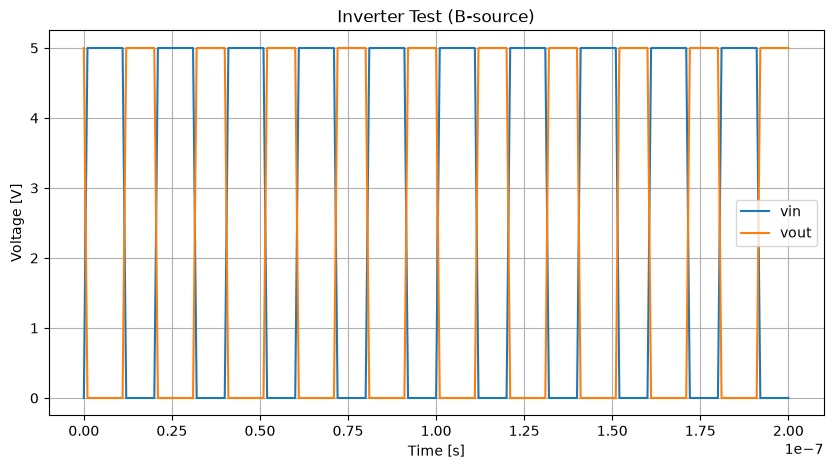

In [ ]:
# 回路作成
circuit = Circuit('Inverter Test')

# 電源
circuit.V('dd', 'Vdd', circuit.gnd, 5@u_V)

# 入力パルス（ノード名を 'vin' に変更）
circuit.PulseVoltageSource('in', 'vin', circuit.gnd,
                           initial_value=0@u_V,
                           pulsed_value=5@u_V,
                           rise_time=1@u_ns,
                           fall_time=1@u_ns,
                           pulse_width=10@u_ns,
                           period=20@u_ns)

# B 素子インバータ
circuit.B('inv', 'vout', circuit.gnd, v='V(Vdd) - V(vin)')

# シミュレーション
simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.transient(step_time=0.1@u_ns, end_time=200@u_ns)

# プロット（Unit を ndarray に変換）
time = analysis.time.as_ndarray()
vin = analysis['vin'].as_ndarray()
vout = analysis['vout'].as_ndarray()

plt.figure(figsize=(10, 5))
plt.plot(time, vin, label='vin')
plt.plot(time, vout, label='vout')
plt.legend()
plt.grid(True)
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.title('Inverter Test (B-source)')
plt.show()

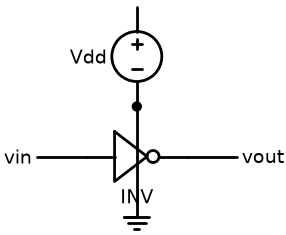

In [13]:
import schemdraw
import schemdraw.elements as elm
import schemdraw.logic as logic

with schemdraw.Drawing() as d:
    d.config(unit=2.0)

    # inverter body
    inv = d.add(logic.Not().at((2.5, 0)).right().label('INV', loc='bottom'))

    # signal path: vin -> INV -> vout
    d += elm.Line().at(inv.start).left(1.0).label('vin', loc='left')
    d += elm.Line().at(inv.end).right(1.0).label('vout', loc='right')

    # power branch: Vdd
    d += elm.Line().at(inv.center).up(1.0)
    d += elm.Dot()
    d += elm.SourceV().up().label('Vdd', loc='top')

    # ground branch: GND
    d += elm.Line().at(inv.center).down(0.8)
    d += elm.Ground()

    d.draw()